In [81]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(100)
np.random.seed(100)

In [82]:
data = load_breast_cancer()
X = data.data
y = data.target

print(np.shape(X))
print(np.shape(y))

(569, 30)
(569,)


In [83]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
  X, y, test_size=0.2, random_state=100, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
  X_trainval, y_trainval, test_size=0.25, random_state=100, stratify=y_trainval
)

In [84]:
#Normalization
scaler = StandardScaler()

X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)
X_val_norm = scaler.transform(X_val)

In [85]:
model = keras.Sequential([
  keras.layers.Input(shape=(30,)),
  keras.layers.Dense(1, activation='sigmoid') #Single neuron
  ])

model.compile(
  optimizer = keras.optimizers.Adam(learning_rate = 0.01),
  loss = 'binary_crossentropy',
  metrics = ['accuracy']
  )

In [86]:
history = model.fit(
  X_train_norm, y_train,
  validation_data=(X_val_norm, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6716 - loss: 0.6321 - val_accuracy: 0.8596 - val_loss: 0.3657
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8915 - loss: 0.2987 - val_accuracy: 0.9035 - val_loss: 0.2385
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9326 - loss: 0.2101 - val_accuracy: 0.9035 - val_loss: 0.1938
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9472 - loss: 0.1721 - val_accuracy: 0.9035 - val_loss: 0.1618
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9560 - loss: 0.1472 - val_accuracy: 0.9123 - val_loss: 0.1440
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9619 - loss: 0.1341 - val_accuracy: 0.9386 - val_loss: 0.1302
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9619 - loss: 0.1238 - val_accuracy: 0.9474 - val_loss: 0.1219
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9648 - loss: 0.1165 - val_accuracy: 0.95

### Adding Hidden Layers

In [87]:
better_model = keras.Sequential([
  keras.layers.Input(shape=(30,)),
  
  #ReLu hidden layers
  keras.layers.Dense(32, activation='relu'),
  keras.layers.Dense(16, activation='relu'),
  keras.layers.Dense(8, activation='relu'),
  
  #Sigmoid output
  keras.layers.Dense(1, activation='sigmoid')
])

better_model.compile(
  optimizer = keras.optimizers.Adam(0.01),
  loss = 'binary_crossentropy',
  metrics = ['accuracy']
)

better_history = better_model.fit(
  X_train_norm, y_train,
  validation_data = (X_val_norm, y_val),
  epochs = 200, batch_size = 32, verbose = 1
)

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9032 - loss: 0.4059 - val_accuracy: 0.9123 - val_loss: 0.1793
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9560 - loss: 0.1155 - val_accuracy: 0.9474 - val_loss: 0.0862
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9765 - loss: 0.0754 - val_accuracy: 0.9737 - val_loss: 0.0624
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0576 - val_accuracy: 0.9825 - val_loss: 0.0573
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9883 - loss: 0.0477 - val_accuracy: 0.9825 - val_loss: 0.0622
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9883 - loss: 0.0440 - val_accuracy: 0.9649 - val_loss: 0.0670
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9912 - loss: 0.0352 - val_accuracy: 0.9649 - val_loss: 0.0709
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9941 - loss: 0.0258 - val_accuracy: 0.9737

# Final Model: 

### Including:
* *Regularization* 
* *Dropout*
* *Early stopping*

In [88]:
final_model = keras.Sequential([
  keras.layers.Input(shape=(30,)),
  
  #Hidden layers
  keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
  keras.layers.Dropout(0.3),

  keras.layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
  keras.layers.Dropout(0.2),

  keras.layers.Dense(16, activation='relu'),

  keras.layers.Dense(1, activation='sigmoid')
])

final_model.compile(
  optimizer = keras.optimizers.Adam(learning_rate = 0.001),
  loss = 'binary_crossentropy',
  metrics = ['accuracy']
)

early_stop = keras.callbacks.EarlyStopping(
  monitor = 'val_loss',
  patience = 25,
  restore_best_weights = True
)

final_history = final_model.fit(
  X_train_norm, y_train,
  validation_data = (X_val_norm, y_val),
  epochs = 500,
  batch_size = 32,
  verbose = 1,
  callbacks = [early_stop]
)

Epoch 1/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7478 - loss: 0.6288 - val_accuracy: 0.8772 - val_loss: 0.4803
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8739 - loss: 0.4498 - val_accuracy: 0.9035 - val_loss: 0.3634
Epoch 3/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9208 - loss: 0.3701 - val_accuracy: 0.9123 - val_loss: 0.2988
Epoch 4/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9355 - loss: 0.2993 - val_accuracy: 0.9211 - val_loss: 0.2578
Epoch 5/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9355 - loss: 0.2591 - val_accuracy: 0.9298 - val_loss: 0.2259
Epoch 6/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9501 - loss: 0.2343 - val_accuracy: 0.9386 - val_loss: 0.2068
Epoch 7/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9501 - loss: 0.2294 - val_accuracy: 0.9386 - val_loss: 0.1886
Epoch 8/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9560 - loss: 0.2006 - val_accuracy: 0.

In [89]:
test_loss, test_accuracy = final_model.evaluate(X_test_norm, y_test, verbose = 0)

print("Accuracy: ", round(test_accuracy, 4))
print("Loss    : ", round(test_loss, 4))

Accuracy:  0.9912
Loss    :  0.085


# Confusion Matrix

      FINAL MODEL — TEST SET EVALUATION
Test Loss:     0.0850
Test Accuracy: 0.9912

              precision    recall  f1-score   support

   Malignant       1.00      0.98      0.99        42
      Benign       0.99      1.00      0.99        72

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



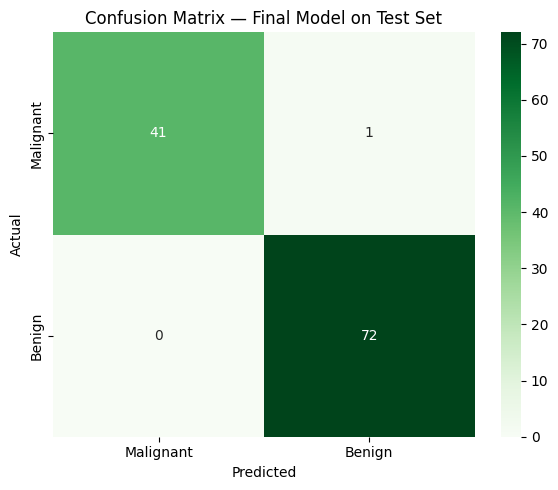

In [90]:
y_pred_proba = final_model.predict(X_test_norm, verbose=0).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print('=' * 53)
print('      FINAL MODEL — TEST SET EVALUATION')
print('=' * 53)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix — Final Model on Test Set', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()